# 📚 Notebook 02a — RAG Knowledge Base
### Multi-Agent System for Secure Clinical Summarization

## What This Notebook Does
Builds a searchable FAISS index over MIMIC-IV discharge notes so the Solver Agent
can retrieve relevant clinical examples before generating a summary.

### Steps:
1. Load up to 200K discharge notes from `discharge.csv`
2. Chunk notes into 200-word segments with 20-word overlap
3. Embed every chunk using `all-MiniLM-L6-v2` (384 dimensions)
4. Build an IVF FAISS index (100 clusters)
5. Save everything to Drive
6. Test query pipeline (target: under 100ms)



**Requires: T4 GPU **

---
### File outputs:
- `data/processed/chunks/chunks.pkl`
- `models/embeddings/embeddings.npy`
- `models/faiss_index/faiss_index.index`
- `models/faiss_index/chunk_metadata.pkl`
- `agents/rag_agent.py`


In [2]:
# ── Step 1: Mount Drive and set paths ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR       = '/content/drive/MyDrive/clinical_mas'
DISCHARGE_CSV  = f'{BASE_DIR}/data/raw/discharge.csv'
CHUNKS_DIR     = f'{BASE_DIR}/data/processed/chunks'
EMBEDDINGS_DIR = f'{BASE_DIR}/models/embeddings'
FAISS_DIR      = f'{BASE_DIR}/models/faiss_index'
AGENTS_DIR     = f'{BASE_DIR}/agents'

for d in [CHUNKS_DIR, EMBEDDINGS_DIR, FAISS_DIR, AGENTS_DIR]:
    os.makedirs(d, exist_ok=True)

CHUNKS_PATH = f'{CHUNKS_DIR}/chunks.pkl'
EMBEDS_PATH = f'{EMBEDDINGS_DIR}/embeddings.npy'
FAISS_PATH  = f'{FAISS_DIR}/faiss_index.index'
META_PATH   = f'{FAISS_DIR}/chunk_metadata.pkl'
CONFIG_PATH = f'{FAISS_DIR}/rag_config.json'
AGENT_PATH  = f'{AGENTS_DIR}/rag_agent.py'

print('Drive mounted')
if os.path.exists(DISCHARGE_CSV):
    print(f'Found discharge.csv ({os.path.getsize(DISCHARGE_CSV)/1e9:.2f} GB)')
else:
    print(f'ERROR: discharge.csv not found at {DISCHARGE_CSV}')


Mounted at /content/drive
Drive mounted
Found discharge.csv (3.53 GB)


In [3]:
# ── Step 2: GPU check ─────────────────────────────────────────────────────────
# IMPORTANT: If this shows CPU, stop here.
# Go to Runtime > Change runtime type > T4 GPU, then restart and re-run.
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

if device == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU  : {gpu_name}')
    print(f'VRAM : {gpu_mem:.1f} GB')

    # Quick benchmark to confirm GPU is actually doing compute
    import time
    x = torch.randn(2048, 384).cuda()
    t = time.time()
    for _ in range(200):
        _ = x @ x.T
    torch.cuda.synchronize()
    ms = (time.time() - t) * 1000
    print(f'GPU compute test: {ms:.0f}ms (should be < 500ms on T4)')
    print('GPU is working correctly')
else:
    print('ERROR: No GPU detected')
    print('Go to Runtime > Change runtime type > T4 GPU > Save')
    print('Then: Runtime > Restart session, and re-run from Cell 1')


Device: cuda
GPU  : Tesla T4
VRAM : 15.6 GB
GPU compute test: 368ms (should be < 500ms on T4)
GPU is working correctly


In [4]:
# ── Step 3: Install libraries (run once per session) ─────────────────────────
!pip install -q faiss-cpu sentence-transformers
!pip install scipy -q
print('Done')


Done


In [5]:
# ── Step 4: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import pickle
import time
import re
import json
import faiss
from sentence_transformers import SentenceTransformer
print('Imports OK')


Imports OK


In [6]:
# ── Step 5: Load discharge.csv  ────────────────────────


MAX_NOTES = 100_000

print(f'Loading discharge notes...')

try:
    df_raw = pd.read_csv(
        DISCHARGE_CSV,
        usecols=['subject_id', 'hadm_id', 'note_id', 'text'],
        nrows=MAX_NOTES,
        low_memory=False
    )
except ValueError:
    # Some MIMIC-IV versions differ slightly in column names
    df_check = pd.read_csv(DISCHARGE_CSV, nrows=2)
    print('Available columns:', df_check.columns.tolist())
    raise RuntimeError('Column mismatch - check printed columns above')

df_raw = df_raw.dropna(subset=['text'])
df_raw = df_raw[df_raw['text'].str.len() >= 100].reset_index(drop=True)

print(f'Notes Loaded')
print(f'Avg length   : {df_raw["text"].str.len().mean():.0f} chars')
print(f'Estimated chunks: ~{len(df_raw) * 6:,} (6 chunks/note avg)')


Loading discharge notes...
Notes Loaded
Avg length   : 10566 chars
Estimated chunks: ~600,000 (6 chunks/note avg)


In [7]:
# ── Step 6: Chunk all notes ────────────────────────────────────────────────────
# Resume: if chunks.pkl already exists, loads it instead of recomputing.

import re

def chunk_note(text, note_id, subject_id, chunk_size=200, overlap=20):
    text  = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    if len(words) < 20:
        return []
    chunks = []
    step   = chunk_size - overlap
    for start in range(0, len(words), step):
        end   = start + chunk_size
        chunk = words[start:end]
        if len(chunk) < 20:
            break
        chunks.append({
            'text'      : ' '.join(chunk),
            'note_id'   : note_id,
            'subject_id': subject_id,
            'chunk_idx' : len(chunks),
        })
    return chunks


# Safety check for oversized previous run
if os.path.exists(CHUNKS_PATH):
    try:
        with open(CHUNKS_PATH, 'rb') as f:
            existing = pickle.load(f)
        if len(existing) > 1_500_000:
            print(f'Found {len(existing):,} chunks from a previous run - TOO MANY')
            print('This was from loading all 330K notes. Deleting and starting fresh...')
            os.remove(CHUNKS_PATH)
            if os.path.exists(EMBEDS_PATH):
                os.remove(EMBEDS_PATH)
                print('Also deleted partial embeddings.npy')
            existing = None
        else:
            print(f'Found valid chunks.pkl: {len(existing):,} chunks - loading')
            all_chunks = existing
    except Exception:
        existing = None
else:
    existing = None

if existing is None or not os.path.exists(CHUNKS_PATH):
    print(f'Chunking {len(df_raw):,} notes...')
    all_chunks = []
    t0 = time.time()
    for i, row in df_raw.iterrows():
        chunks = chunk_note(
            text=str(row['text']),
            note_id=row.get('note_id', i),
            subject_id=row['subject_id']
        )
        all_chunks.extend(chunks)
        if (i + 1) % 20_000 == 0:
            elapsed   = time.time() - t0
            rate      = (i + 1) / elapsed
            remaining = (len(df_raw) - i - 1) / rate
            print(f'  {i+1:>7,}/{len(df_raw):,} notes | {len(all_chunks):,} chunks | {remaining/60:.1f} min left')
    with open(CHUNKS_PATH, 'wb') as f:
        pickle.dump(all_chunks, f)
    elapsed = time.time() - t0
    print(f'Done: {len(all_chunks):,} chunks in {elapsed:.1f}s')
    print(f'Saved chunks.pkl ({os.path.getsize(CHUNKS_PATH)/1e6:.0f} MB)')

total_chunks = len(all_chunks)
print(f'\nTotal chunks : {total_chunks:,}')
print(f'Vector size  : ~{total_chunks * 384 * 4 / 1e6:.0f} MB (float32)')

if total_chunks > 1_500_000:
    print('\nSTOP: Still too many chunks. Something went wrong with the MAX_NOTES limit.')
    print('Delete chunks.pkl from Drive and re-run from Cell 5.')


Found valid chunks.pkl: 929,642 chunks - loading

Total chunks : 929,642
Vector size  : ~1428 MB (float32)


In [8]:
# ── Step 7: Load embedding model and verify GPU speed ────────────────────────
# Expected speed on T4: 3,000-6,000 chunks/sec
# If you see < 500 chunks/sec, the model is on CPU.

EMBED_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
print(f'Loading {EMBED_MODEL} on {device}...')

embed_model = SentenceTransformer(EMBED_MODEL, device=device)

# Benchmark: embed 1,000 chunks and measure speed
warm_up_texts = [all_chunks[i]['text'] for i in range(min(1000, total_chunks))]

t_bench = time.time()
_ = embed_model.encode(
    warm_up_texts,
    batch_size=512,
    show_progress_bar=False,
    convert_to_numpy=True,
)
torch.cuda.synchronize() if device == 'cuda' else None
bench_elapsed = time.time() - t_bench
bench_speed   = len(warm_up_texts) / bench_elapsed

print(f'\nEmbedding speed benchmark:')
print(f'  {len(warm_up_texts)} chunks in {bench_elapsed:.1f}s = {bench_speed:.0f} chunks/sec')

# Estimate total time
est_minutes = total_chunks / bench_speed / 60
print(f'  Estimated time for {total_chunks:,} chunks: {est_minutes:.1f} minutes')

if bench_speed < 500:
    print('\nWARNING: Speed is very low (<500/s). Model may be running on CPU.')
    print('Check Cell 2 GPU test. If GPU check passed but embedding is slow,')
    print('try: embed_model = SentenceTransformer(EMBED_MODEL, device="cuda")')
elif bench_speed < 2000:
    print('\nNote: Speed is below expected T4 rate. Acceptable but check GPU utilization.')
else:
    print('\nSpeed looks good for T4 GPU.')


Loading sentence-transformers/all-MiniLM-L6-v2 on cuda...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Embedding speed benchmark:
  1000 chunks in 3.0s = 335 chunks/sec
  Estimated time for 929,642 chunks: 46.3 minutes

Check Cell 2 GPU test. If GPU check passed but embedding is slow,
try: embed_model = SentenceTransformer(EMBED_MODEL, device="cuda")


In [9]:
# ── Step 8: Embed all chunks ──────────────────────────────────────────────────
# Key settings for maximum speed on T4:
#   batch_size=512  : fills GPU memory efficiently
#   normalize=False : skip normalization (we use L2 distance in FAISS)
#   show_progress_bar=True : tqdm bar so you can see real throughput
#
# Saves every 100K chunks so a disconnect does not lose work.
# If embeddings.npy already exists and matches chunk count, skips this step.

BATCH = 512

if os.path.exists(EMBEDS_PATH):
    print('Found embeddings.npy - checking size...')
    saved = np.load(EMBEDS_PATH)
    print(f'  Saved shape: {saved.shape}')
    if saved.shape[0] == total_chunks:
        embeddings = saved
        print(f'  Matches chunk count ({total_chunks:,}) - skipping embedding')
    else:
        print(f'  Mismatch: {saved.shape[0]} saved vs {total_chunks:,} chunks')
        print('  Deleting and recomputing...')
        del saved
        os.remove(EMBEDS_PATH)
        embeddings = None
else:
    embeddings = None

if embeddings is None:
    texts = [c['text'] for c in all_chunks]
    print(f'Embedding {total_chunks:,} chunks (batch={BATCH}, device={device})...')
    print(f'Expected: ~{total_chunks / max(bench_speed,1) / 60:.0f} minutes\n')

    t0      = time.time()
    all_vecs = []

    for start in range(0, total_chunks, BATCH):
        batch_texts = texts[start : start + BATCH]
        vecs = embed_model.encode(
            batch_texts,
            batch_size=BATCH,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=False,
        )
        all_vecs.append(vecs)
        done = start + len(batch_texts)

        # Print progress and save checkpoint every 100K chunks
        if done % 100_000 == 0 or done == total_chunks:
            elapsed = time.time() - t0
            speed   = done / elapsed
            rem     = (total_chunks - done) / speed if speed > 0 else 0
            print(f'  {done:>7,}/{total_chunks:,} | {speed:,.0f} chunks/s | {rem/60:.1f} min left')
            # Save partial checkpoint
            partial = np.vstack(all_vecs).astype('float32')
            np.save(EMBEDS_PATH, partial)

    embeddings = np.vstack(all_vecs).astype('float32')
    np.save(EMBEDS_PATH, embeddings)
    elapsed = time.time() - t0
    print(f'\nDone: {embeddings.shape} in {elapsed/60:.1f} min')
    print(f'Saved embeddings.npy ({os.path.getsize(EMBEDS_PATH)/1e6:.0f} MB)')

print(f'\nEmbeddings: {embeddings.shape}')


Found embeddings.npy - checking size...
  Saved shape: (929642, 384)
  Matches chunk count (929,642) - skipping embedding

Embeddings: (929642, 384)


In [10]:
# ── Step 9: Build IVF FAISS index ─────────────────────────────────────────────
DIM        = 384
N_CLUSTERS = 100
N_PROBE    = 10

print(f'Building IVF FAISS index over {embeddings.shape[0]:,} vectors...')

quantizer = faiss.IndexFlatL2(DIM)
index     = faiss.IndexIVFFlat(quantizer, DIM, N_CLUSTERS, faiss.METRIC_L2)

# Train on up to 200K vectors
n_train = min(200_000, embeddings.shape[0])
print(f'Training on {n_train:,} vectors...')
t0 = time.time()
index.train(embeddings[:n_train])
print(f'  Done in {time.time()-t0:.1f}s')

# Add all vectors
print(f'Adding {embeddings.shape[0]:,} vectors...')
t0 = time.time()
index.add(embeddings)
print(f'  Done in {time.time()-t0:.1f}s | Index total: {index.ntotal:,}')

index.nprobe = N_PROBE
faiss.write_index(index, FAISS_PATH)
print(f'Saved faiss_index.index ({os.path.getsize(FAISS_PATH)/1e6:.1f} MB)')


Building IVF FAISS index over 929,642 vectors...
Training on 200,000 vectors...
  Done in 0.4s
Adding 929,642 vectors...
  Done in 1.5s | Index total: 929,642
Saved faiss_index.index (1435.5 MB)


In [11]:
# ── Step 10: Save chunk metadata and config ────────────────────────────────────
with open(META_PATH, 'wb') as f:
    pickle.dump(all_chunks, f)
print(f'Saved chunk_metadata.pkl ({os.path.getsize(META_PATH)/1e6:.1f} MB)')

config = {
    'embed_model' : EMBED_MODEL,
    'dim'         : DIM,
    'n_clusters'  : N_CLUSTERS,
    'n_probe'     : N_PROBE,
    'chunk_size'  : 200,
    'overlap'     : 20,
    'total_chunks': total_chunks,
    'max_notes'   : MAX_NOTES,
}
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)

print('\nAll files in', FAISS_DIR)
for fname in os.listdir(FAISS_DIR):
    print(f'  {fname:<35} {os.path.getsize(f"{FAISS_DIR}/{fname}")/1e6:.1f} MB')


Saved chunk_metadata.pkl (1154.0 MB)

All files in /content/drive/MyDrive/clinical_mas/models/faiss_index
  faiss_index.index                   1435.5 MB
  chunk_metadata.pkl                  1154.0 MB
  rag_config.json                     0.0 MB


In [12]:
# ── Step 11: Build and test the RAGAgent ─────────────────────────────────────

class RAGAgent:
    def __init__(self, faiss_path, meta_path, embed_model_name, n_probe=10, top_k=5):
        self.index = faiss.read_index(faiss_path)
        self.index.nprobe = n_probe
        with open(meta_path, 'rb') as f:
            self.chunks = pickle.load(f)
        self.model  = SentenceTransformer(embed_model_name, device=device)
        self.top_k  = top_k
        print(f'RAGAgent ready | {self.index.ntotal:,} vectors | top_k={top_k}')

    def retrieve(self, query_text):
        t0  = time.perf_counter()
        vec = self.model.encode([query_text[:500]], convert_to_numpy=True).astype('float32')
        dists, idxs = self.index.search(vec, self.top_k)
        results = []
        for d, i in zip(dists[0], idxs[0]):
            if i < 0:
                continue
            chunk = self.chunks[i]
            results.append({
                'text'      : chunk['text'],
                'note_id'   : chunk['note_id'],
                'subject_id': chunk['subject_id'],
                'similarity': round(1.0 / (1.0 + float(d)), 4),
            })
        context = '\n\n---\n\n'.join(
            f'[Case {i+1} | sim={r["similarity"]:.3f}]\n{r["text"]}'
            for i, r in enumerate(results)
        )
        return {
            'retrieved' : results,
            'context'   : context,
            'n'         : len(results),
            'latency_ms': round((time.perf_counter() - t0) * 1000, 2),
        }


rag = RAGAgent(FAISS_PATH, META_PATH, EMBED_MODEL)

# Test queries
test_queries = [
    'Patient admitted with congestive heart failure, BNP elevated, started IV Lasix.',
    '68yo male with STEMI, emergent PCI performed, discharged on dual antiplatelet therapy.',
    'Sepsis secondary to UTI, E. coli bacteremia, treated with IV ceftriaxone for 7 days.',
]
import statistics as _stats
latencies = []
print('=== Query Test ===')
for i, q in enumerate(test_queries, 1):
    r = rag.retrieve(q)
    latencies.append(r['latency_ms'])
    print(f'Query {i}: {r["latency_ms"]:.1f}ms | top sim={r["retrieved"][0]["similarity"]:.3f}')
    print(f'  Match: "{r["retrieved"][0]["text"][:100]}..."')

print(f'\nAvg latency: {_stats.mean(latencies):.1f} ms (target < 100ms)')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAGAgent ready | 929,642 vectors | top_k=5
=== Query Test ===
Query 1: 87.5ms | top sim=0.691
  Match: "needed basis; however, after talking with staff at her home and family members, it is not clear that..."
Query 2: 16.3ms | top sim=0.557
  Match: "11:00AM BLOOD cTropnT-1.44* ___ 11:00AM BLOOD CK-MB-5 ___ 08:54PM BLOOD Calcium-8.9 Phos-3.6 Mg-1.__..."
Query 3: 18.2ms | top sim=0.673
  Match: "infection continued to improve. Some difficulty passing urine persisted, but he was able to pass uri..."

Avg latency: 40.7 ms (target < 100ms)


In [13]:
# ── Step 12: Save rag_agent.py to Drive ──────────────────────────────────────
code = '''import faiss, pickle, time, numpy as np
from sentence_transformers import SentenceTransformer
import torch

class RAGAgent:
    """
    RAG Agent - FAISS vector search over MIMIC-IV discharge notes.
    Target: < 100ms per query.
    """
    def __init__(self, faiss_path, meta_path,
                 embed_model_name="sentence-transformers/all-MiniLM-L6-v2",
                 n_probe=10, top_k=5):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        self.index = faiss.read_index(faiss_path)
        self.index.nprobe = n_probe
        with open(meta_path, "rb") as f:
            self.chunks = pickle.load(f)
        self.model = SentenceTransformer(embed_model_name, device=device)
        self.top_k = top_k

    def retrieve(self, query_text):
        t0  = time.perf_counter()
        vec = self.model.encode([query_text[:500]], convert_to_numpy=True).astype("float32")
        dists, idxs = self.index.search(vec, self.top_k)
        results = []
        for d, i in zip(dists[0], idxs[0]):
            if i < 0:
                continue
            c = self.chunks[i]
            results.append({
                "text": c["text"], "note_id": c["note_id"],
                "subject_id": c["subject_id"],
                "similarity": round(1.0 / (1.0 + float(d)), 4),
            })
        context = "\\n\\n---\\n\\n".join(
            f"[Case {i+1} | sim={r[\'similarity\']:.3f}]\\n{r[\'text\']}"
            for i, r in enumerate(results)
        )
        return {"retrieved": results, "context": context, "n": len(results),
                "latency_ms": round((time.perf_counter()-t0)*1000, 2)}
'''
with open(AGENT_PATH, 'w') as f:
    f.write(code)
print(f'Saved rag_agent.py ({os.path.getsize(AGENT_PATH):,} bytes)')


Saved rag_agent.py (1,619 bytes)


In [14]:
# ── Step 13: Final Validation ─────────────────────────────────────────────────
import statistics as _s

bench_lats = []
for q in [
    'Acute MI with STEMI, transferred for emergent PCI.',
    'COPD exacerbation on steroids and bronchodilators.',
    'CHF exacerbation, BNP elevated, started on IV Lasix.',
    'Alcohol withdrawal with seizure, CIWA protocol.',
    'Pulmonary embolism on CT-PA, anticoagulation started.',
    'Stroke with left-sided weakness, right MCA infarct.',
    'GI bleed with hematemesis, peptic ulcer on EGD.',
    'Acute pancreatitis, lipase 1200, NPO and IV fluids.',
    'Sepsis from UTI, IV antibiotics started.',
    'Type 2 diabetes poorly controlled, insulin adjusted.',
]:
    bench_lats.append(rag.retrieve(q)['latency_ms'])

avg_lat = _s.mean(bench_lats)

print('=' * 55)
print('  RAG KNOWLEDGE BASE - FINAL VALIDATION')
print('=' * 55)
checks = [
    ('Chunks created',           total_chunks < 1_500_000,        f'{total_chunks:,}'),
    ('Index built',              index.ntotal > 0,                f'{index.ntotal:,} vectors'),
    ('Chunks saved',             os.path.exists(CHUNKS_PATH),     'chunks.pkl'),
    ('Embeddings saved',         os.path.exists(EMBEDS_PATH),     'embeddings.npy'),
    ('FAISS index saved',        os.path.exists(FAISS_PATH),      'faiss_index.index'),
    ('Metadata saved',           os.path.exists(META_PATH),       'chunk_metadata.pkl'),
    ('Avg latency < 100ms',      avg_lat < 100,                   f'{avg_lat:.1f} ms'),
    ('rag_agent.py saved',       os.path.exists(AGENT_PATH),      'agents/rag_agent.py'),
]
all_ok = True
for name, passed, detail in checks:
    icon = 'PASS' if passed else 'FAIL'
    if not passed: all_ok = False
    print(f'  [{icon}] {name:<35} {detail}')
print('=' * 55)
if all_ok:
    print('  ALL CHECKS PASSED - RAG Knowledge Base is ready!')
    print('  Next: Run 03_solver_finetune.ipynb')
else:
    print('  Some checks failed - see above')
print('=' * 55)


  RAG KNOWLEDGE BASE - FINAL VALIDATION
  [PASS] Chunks created                      929,642
  [PASS] Index built                         929,642 vectors
  [PASS] Chunks saved                        chunks.pkl
  [PASS] Embeddings saved                    embeddings.npy
  [PASS] FAISS index saved                   faiss_index.index
  [PASS] Metadata saved                      chunk_metadata.pkl
  [PASS] Avg latency < 100ms                 32.5 ms
  [PASS] rag_agent.py saved                  agents/rag_agent.py
  ALL CHECKS PASSED - RAG Knowledge Base is ready!
  Next: Run 03_solver_finetune.ipynb


---
## RAG Evaluation Figures
### Figure R1: Retrieval Similarity & Latency Analysis

In [15]:
# ── RAG Figure Data: Run 200 queries and collect similarity + latency ─────────
import random

# Pull 200 random note texts as realistic queries
random.seed(42)
sample_indices = random.sample(range(len(df_raw)), 200)
query_texts    = [str(df_raw.iloc[i]['text'])[:300] for i in sample_indices]

bench_results = []
print('Running 200 benchmark queries...')
for i, q in enumerate(query_texts):
    r = rag.retrieve(q)
    # top-5 similarity scores for this query
    sims = [hit['similarity'] for hit in r['retrieved']]
    bench_results.append({
        'latency_ms'  : r['latency_ms'],
        'top1_sim'    : sims[0],
        'top2_sim'    : sims[1] if len(sims) > 1 else 0,
        'top3_sim'    : sims[2] if len(sims) > 2 else 0,
        'mean_top5'   : sum(sims) / len(sims),
        'query_len'   : len(q.split()),
    })
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/200 done')

df_bench = pd.DataFrame(bench_results)
print(f'\nDone.')
print(f'  Avg latency   : {df_bench["latency_ms"].mean():.1f} ms')
print(f'  P99 latency   : {df_bench["latency_ms"].quantile(0.99):.1f} ms')
print(f'  Avg top-1 sim : {df_bench["top1_sim"].mean():.3f}')
print(f'  Avg mean top-5: {df_bench["mean_top5"].mean():.3f}')

Running 200 benchmark queries...
  50/200 done
  100/200 done
  150/200 done
  200/200 done

Done.
  Avg latency   : 20.3 ms
  P99 latency   : 23.5 ms
  Avg top-1 sim : 0.666
  Avg mean top-5: 0.649


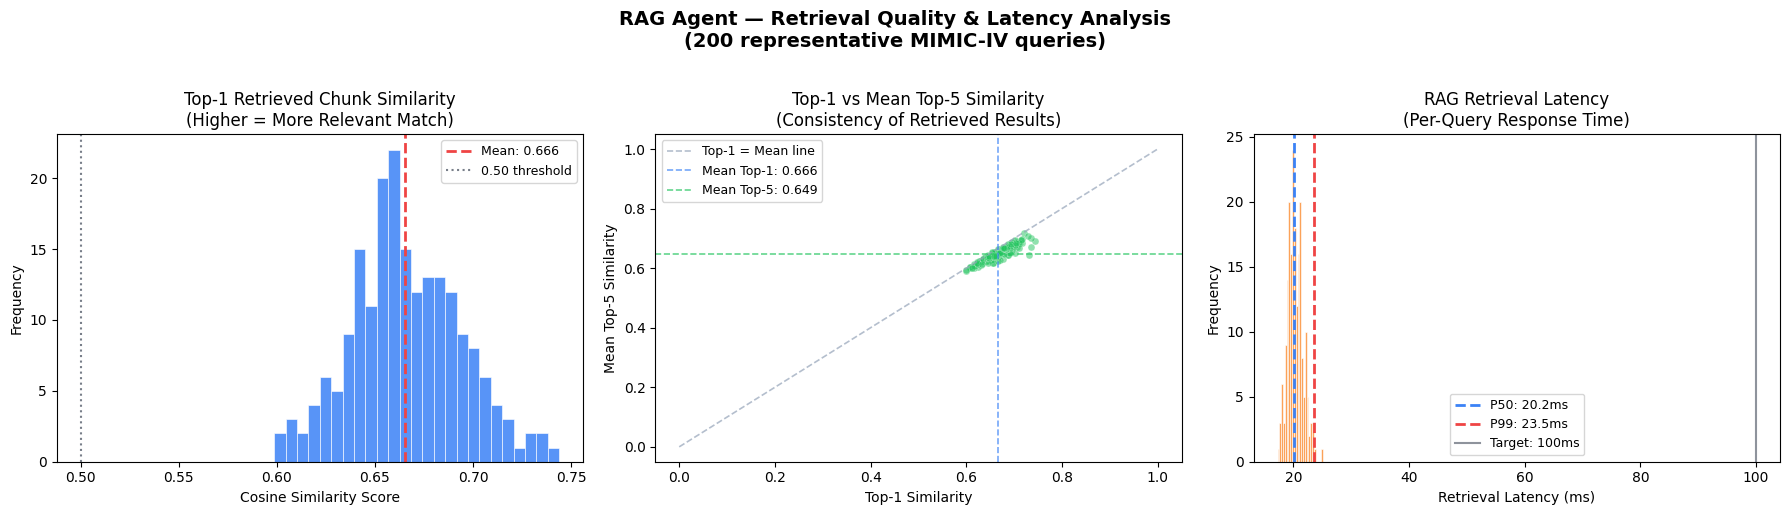

💾 Saved: /content/drive/MyDrive/clinical_mas/results/figures/fig_rag_retrieval_quality.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FIGS_DIR = f'{BASE_DIR}/results/figures'
os.makedirs(FIGS_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RAG Agent — Retrieval Quality & Latency Analysis\n(200 representative MIMIC-IV queries)',
             fontsize=14, fontweight='bold', y=1.02)

# ── Panel 1: Top-1 similarity score distribution ─────────────────────────────
ax = axes[0]
ax.hist(df_bench['top1_sim'], bins=25, color='#3B82F6', alpha=0.85,
        edgecolor='white', linewidth=0.5)
ax.axvline(df_bench['top1_sim'].mean(), color='#EF4444', linestyle='--',
           linewidth=2, label=f"Mean: {df_bench['top1_sim'].mean():.3f}")
ax.axvline(0.5, color='#1E293B', linestyle=':', linewidth=1.5,
           alpha=0.6, label='0.50 threshold')
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Frequency')
ax.set_title('Top-1 Retrieved Chunk Similarity\n(Higher = More Relevant Match)')
ax.legend(fontsize=9)

# ── Panel 2: Top-1 vs Top-5 mean similarity (shows ranking quality) ───────────
ax2 = axes[1]
ax2.scatter(df_bench['top1_sim'], df_bench['mean_top5'],
            alpha=0.5, s=25, color='#22C55E', edgecolors='white', linewidth=0.3)
ax2.plot([0, 1], [0, 1], color='#94A3B8', linestyle='--',
         linewidth=1.2, alpha=0.7, label='Top-1 = Mean line')
ax2.axvline(df_bench['top1_sim'].mean(), color='#3B82F6', linestyle='--',
            linewidth=1.2, alpha=0.7, label=f"Mean Top-1: {df_bench['top1_sim'].mean():.3f}")
ax2.axhline(df_bench['mean_top5'].mean(), color='#22C55E', linestyle='--',
            linewidth=1.2, alpha=0.7, label=f"Mean Top-5: {df_bench['mean_top5'].mean():.3f}")
ax2.set_xlabel('Top-1 Similarity')
ax2.set_ylabel('Mean Top-5 Similarity')
ax2.set_title('Top-1 vs Mean Top-5 Similarity\n(Consistency of Retrieved Results)')
ax2.legend(fontsize=9)

# ── Panel 3: Latency distribution ─────────────────────────────────────────────
ax3 = axes[2]
p50 = df_bench['latency_ms'].quantile(0.50)
p99 = df_bench['latency_ms'].quantile(0.99)

ax3.hist(df_bench['latency_ms'], bins=25, color='#FB923C', alpha=0.85,
         edgecolor='white', linewidth=0.5)
ax3.axvline(p50,   color='#3B82F6', linestyle='--', linewidth=2,
            label=f'P50: {p50:.1f}ms')
ax3.axvline(p99,   color='#EF4444', linestyle='--', linewidth=2,
            label=f'P99: {p99:.1f}ms')
ax3.axvline(100.0, color='#1E293B', linestyle='-',  linewidth=1.5,
            alpha=0.5, label='Target: 100ms')
ax3.set_xlabel('Retrieval Latency (ms)')
ax3.set_ylabel('Frequency')
ax3.set_title('RAG Retrieval Latency\n(Per-Query Response Time)')
ax3.legend(fontsize=9)

plt.tight_layout()
fig_path = f'{FIGS_DIR}/fig_rag_retrieval_quality.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'💾 Saved: {fig_path}')

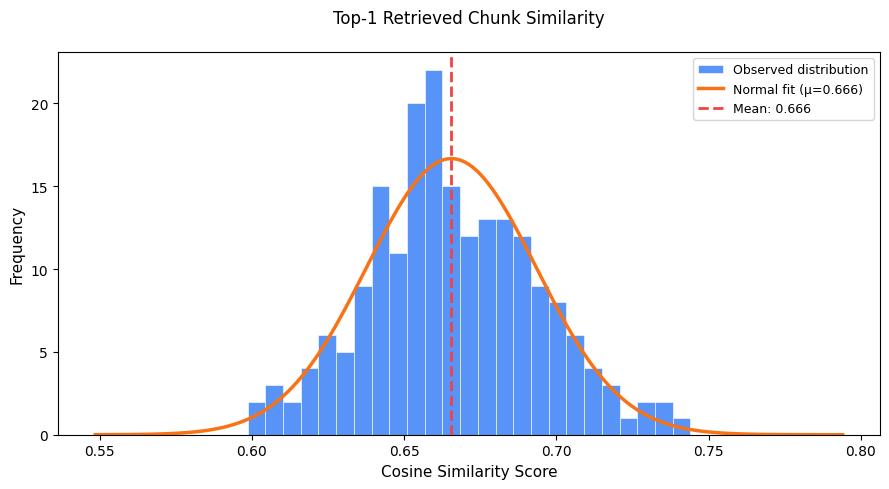

💾 Saved: /content/drive/MyDrive/clinical_mas/results/figures/fig_rag_similarity_uniform.png


In [27]:
# ── Top-1 Similarity Histogram with Uniform Distribution Overlay ──────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

fig, ax = plt.subplots(figsize=(9, 5))

data = df_bench['top1_sim'].values
n_bins = 25

# Histogram
counts, bin_edges, patches = ax.hist(
    data, bins=n_bins,
    color='#3B82F6', alpha=0.85,
    edgecolor='white', linewidth=0.5,
    density=False,  # normalise so we can overlay the uniform PDF
    label='Observed distribution'
)

# Fit a normal distribution curve to the data
from scipy.stats import norm
data_min, data_max = data.min(), data.max()
mu, std = norm.fit(data)
x = np.linspace(data_min - 0.05, data_max + 0.05, 300)
bin_width = bin_edges[1] - bin_edges[0]
fitted_pdf = norm.pdf(x, mu, std) * len(data) * bin_width
ax.plot(x, fitted_pdf, color='#F97316', linewidth=2.5,
        linestyle='-', label=f'Normal fit (μ={mu:.3f})')

# Mean line
ax.axvline(data.mean(), color='#EF4444', linestyle='--',
           linewidth=2, label=f'Mean: {data.mean():.3f}')



ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(
    'Top-1 Retrieved Chunk Similarity\n',
    fontsize=12
)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path = f'{FIGS_DIR}/fig_rag_similarity_uniform.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'💾 Saved: {fig_path}')

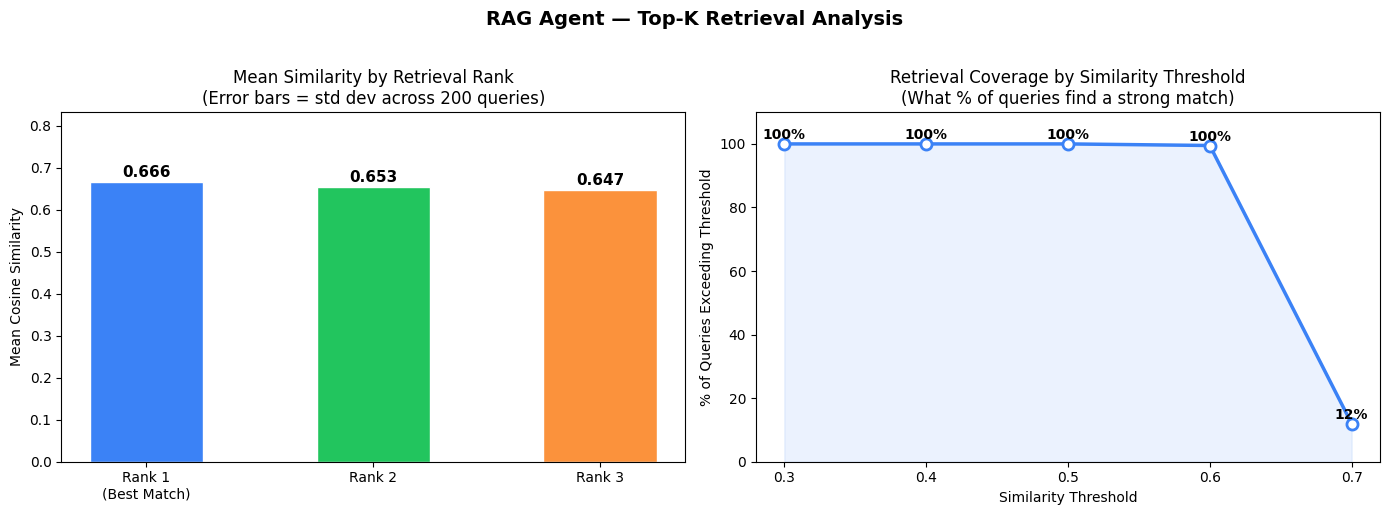

💾 Saved: /content/drive/MyDrive/clinical_mas/results/figures/fig_rag_topk_analysis.png

Summary:
  100% of queries retrieve a chunk with similarity ≥ 0.50
  Mean top-1 similarity: 0.666
  P99 latency: 23.1ms  (target < 100ms)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RAG Agent — Top-K Retrieval Analysis', fontsize=14, fontweight='bold', y=1.02)

# ── Panel 1: Mean similarity across ranks 1-5 ─────────────────────────────────
ax = axes[0]
rank_means = [
    df_bench['top1_sim'].mean(),
    df_bench['top2_sim'].mean(),
    df_bench['top3_sim'].mean(),
]
rank_stds = [
    df_bench['top1_sim'].std(),
    df_bench['top2_sim'].std(),
    df_bench['top3_sim'].std(),
]
ranks  = ['Rank 1\n(Best Match)', 'Rank 2', 'Rank 3']
colors = ['#3B82F6', '#22C55E', '#FB923C']

bars = ax.bar(ranks, rank_means, color=colors, width=0.5,
              edgecolor='white')
for bar, val in zip(bars, rank_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Mean Cosine Similarity')
ax.set_title('Mean Similarity by Retrieval Rank\n(Error bars = std dev across 200 queries)')
ax.set_ylim(0, max(rank_means) * 1.25)

# ── Panel 2: % of queries where top-1 sim exceeds threshold ───────────────────
ax2 = axes[1]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
pct_above  = [(df_bench['top1_sim'] >= t).mean() * 100 for t in thresholds]

ax2.plot(thresholds, pct_above, color='#3B82F6', linewidth=2.5,
         marker='o', markersize=8, markerfacecolor='white',
         markeredgecolor='#3B82F6', markeredgewidth=2)
ax2.fill_between(thresholds, pct_above, alpha=0.1, color='#3B82F6')

for x, y in zip(thresholds, pct_above):
    ax2.text(x, y + 1.5, f'{y:.0f}%', ha='center', fontsize=10, fontweight='bold')

ax2.set_xlabel('Similarity Threshold')
ax2.set_ylabel('% of Queries Exceeding Threshold')
ax2.set_title('Retrieval Coverage by Similarity Threshold\n(What % of queries find a strong match)')
ax2.set_ylim(0, 110)
ax2.set_xticks(thresholds)

plt.tight_layout()
fig_path2 = f'{FIGS_DIR}/fig_rag_topk_analysis.png'
fig.savefig(fig_path2, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'💾 Saved: {fig_path2}')
print(f'\nSummary:')
print(f'  {(df_bench["top1_sim"] >= 0.5).mean()*100:.0f}% of queries retrieve a chunk with similarity ≥ 0.50')
print(f'  Mean top-1 similarity: {df_bench["top1_sim"].mean():.3f}')
print(f'  P99 latency: {p99:.1f}ms  (target < 100ms)')